<a href="https://colab.research.google.com/github/venkat269/P300_BCI_EEG_Preprocessing_Pipeline/blob/main/P300_BCI_EEG_Preprocessing_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the libraries required for EEG processing and CNN training

!pip -q install mne tensorflow scikit-learn seaborn

In [ ]:
# Import all required libraries

import os
import re
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

np.random.seed(42)
tf.random.set_seed(42)

print("MNE version:", mne.__version__)
print("TensorFlow version:", tf.__version__)

MNE version: 1.13.2
TensorFlow version: 2.20.0


In [ ]:
# Download exactly 2 subjects × 3 recordings = 6 EDF files

BASE_URL = "https://physionet.org/files/erpbci/1.0.0"
DATA_DIR = "/content/erpbci_data"

os.makedirs(DATA_DIR, exist_ok=True)

recordings = []

for subject in ["s01", "s02"]:
    subject_dir = os.path.join(DATA_DIR, subject)
    os.makedirs(subject_dir, exist_ok=True)

    for run in ["rc01", "rc02", "rc03"]:
        filename = f"{run}.edf"
        url = f"{BASE_URL}/{subject}/{filename}"
        filepath = os.path.join(subject_dir, filename)

        if not os.path.exists(filepath):
            print(f"Downloading {subject}/{filename} ...")
            urllib.request.urlretrieve(url, filepath)

        recordings.append(filepath)

print("\nTotal recordings:", len(recordings))
for f in recordings:
    print(f)


Total recordings: 6
/content/erpbci_data/s01/rc01.edf
/content/erpbci_data/s01/rc02.edf
/content/erpbci_data/s01/rc03.edf
/content/erpbci_data/s02/rc01.edf
/content/erpbci_data/s02/rc02.edf
/content/erpbci_data/s02/rc03.edf


In [ ]:
# Verify that all six recordings exist and have non-zero file size

valid_files = []

for filepath in recordings:
    exists = os.path.exists(filepath)
    size_mb = os.path.getsize(filepath) / (1024 * 1024) if exists else 0

    print(
        os.path.basename(os.path.dirname(filepath)),
        os.path.basename(filepath),
        "->",
        f"{size_mb:.2f} MB"
    )

    if exists and size_mb > 0:
        valid_files.append(filepath)

print("\nValid recordings:", len(valid_files))

if len(valid_files) != 6:
    raise RuntimeError(
        f"Expected 6 recordings, but only {len(valid_files)} are available."
    )

s01 rc01.edf -> 12.64 MB
s01 rc02.edf -> 7.42 MB
s01 rc03.edf -> 7.70 MB
s02 rc01.edf -> 7.70 MB
s02 rc02.edf -> 7.70 MB
s02 rc03.edf -> 7.97 MB

Valid recordings: 6


In [ ]:
# Load all six EDF recordings

raw_data = {}

for filepath in valid_files:

    subject = os.path.basename(os.path.dirname(filepath))
    run = os.path.splitext(os.path.basename(filepath))[0]

    key = f"{subject}_{run}"

    print(f"Loading {key} ...")

    raw = mne.io.read_raw_edf(
        filepath,
        preload=True,
        verbose=False
    )

    raw_data[key] = raw

print("\nLoaded recordings:", len(raw_data))

for key, raw in raw_data.items():
    print(
        key,
        "| channels:", len(raw.ch_names),
        "| duration:", round(raw.times[-1], 2), "seconds"
    )

Loading s01_rc01 ...
Loading s01_rc02 ...
Loading s01_rc03 ...
Loading s02_rc01 ...
Loading s02_rc02 ...
Loading s02_rc03 ...

Loaded recordings: 6
s01_rc01 | channels: 70 | duration: 46.0 seconds
s01_rc02 | channels: 70 | duration: 27.0 seconds
s01_rc03 | channels: 70 | duration: 28.0 seconds
s02_rc01 | channels: 70 | duration: 28.0 seconds
s02_rc02 | channels: 70 | duration: 28.0 seconds
s02_rc03 | channels: 70 | duration: 29.0 seconds


In [ ]:
# Check EEG sampling rate and channel names

for name, raw in raw_data.items():

    print("\n", name)
    print("Sampling frequency:", raw.info["sfreq"])
    print("Number of channels:", len(raw.ch_names))
    print("Channels:", raw.ch_names[:10])


 s01_rc01
Sampling frequency: 2048.0
Number of channels: 70
Channels: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']

 s01_rc02
Sampling frequency: 2048.0
Number of channels: 70
Channels: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']

 s01_rc03
Sampling frequency: 2048.0
Number of channels: 70
Channels: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']

 s02_rc01
Sampling frequency: 2048.0
Number of channels: 70
Channels: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']

 s02_rc02
Sampling frequency: 2048.0
Number of channels: 70
Channels: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']

 s02_rc03
Sampling frequency: 2048.0
Number of channels: 70
Channels: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']


In [44]:
# Select EEG channels, average reference and downsample

TARGET_FS = 256

processed_raw = {}

for name, raw in raw_data.items():

    r = raw.copy()

    # Average-ear reference if available
    if "EARL" in r.ch_names and "EARR" in r.ch_names:
        r.set_eeg_reference(
            ref_channels=["EARL", "EARR"],
            projection=False,
            verbose=False
        )

    exclude = [
        "EARL", "EARR",
        "VEOGL", "VEOGR",
        "HEOGL", "HEOGR",
        "EDF Annotations"
    ]

    eeg_channels = [
        ch for ch in r.ch_names
        if ch not in exclude
    ]

    r.pick(eeg_channels)

    r.resample(TARGET_FS)

    processed_raw[name] = r

print("Preprocessing preparation completed.")

Preprocessing preparation completed.


In [45]:
# Remove 50 Hz power-line noise

for name, raw in processed_raw.items():

    raw.notch_filter(
        freqs=[50],
        verbose=False
    )

print("Notch filtering completed.")

Notch filtering completed.


In [46]:
# Keep useful EEG frequencies

for name, raw in processed_raw.items():

    raw.filter(
        l_freq=0.5,
        h_freq=30,
        verbose=False
    )

print("Band-pass filtering completed.")

Band-pass filtering completed.


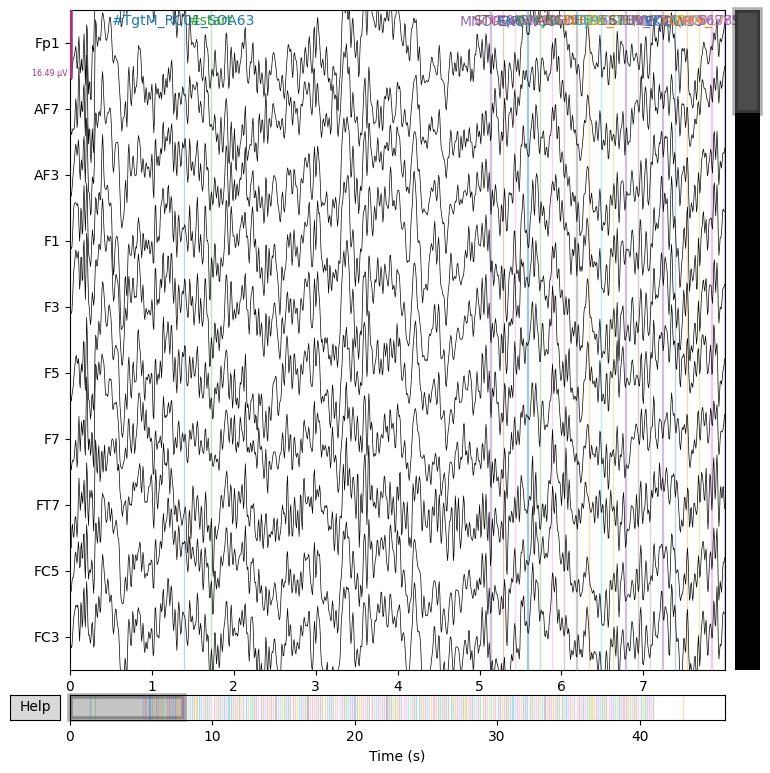

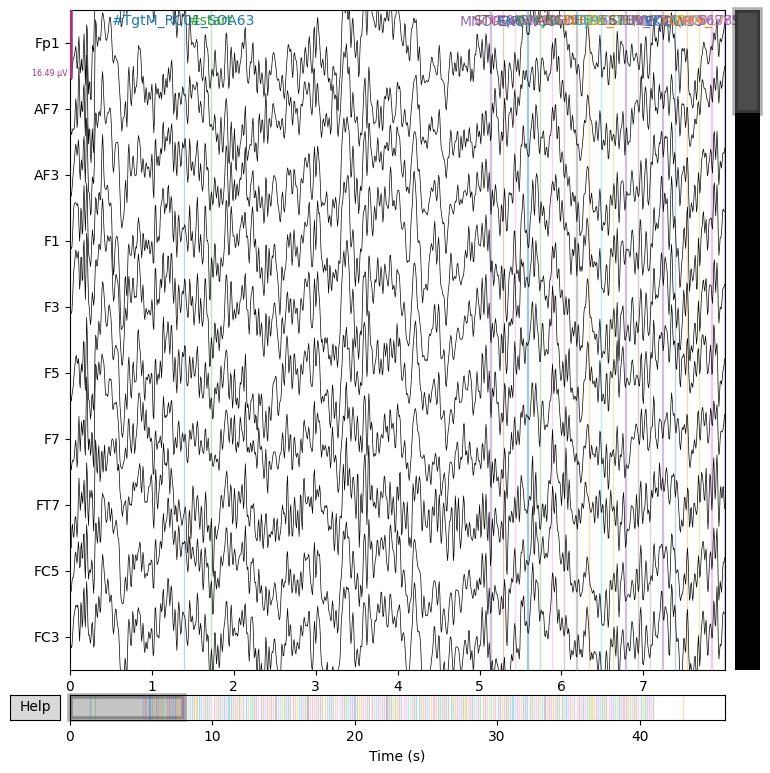

In [47]:
# Display preprocessed EEG

first_processed = list(processed_raw.values())[0]

first_processed.plot(
    duration=8,
    n_channels=10,
    scalings="auto"
)

In [48]:
# Convert EEG stimulus events into Target and Non-target epochs

all_X = []
all_y = []

for name, raw in processed_raw.items():

    descriptions = raw.annotations.description
    onsets = raw.annotations.onset

    target_char = None

    # Find target character
    for desc in descriptions:

        if str(desc).startswith("#Tgt"):

            match = re.search(r"#Tgt(.)_", str(desc))

            if match:
                target_char = match.group(1)
                break

    print("\n", name)
    print("Target character:", target_char)

    events = []

    for onset, desc in zip(onsets, descriptions):

        desc = str(desc)

        if desc.startswith("#"):
            continue

        if target_char is None:
            continue

        label = 1 if target_char in desc else 0

        sample = int(onset * raw.info["sfreq"])

        event_id = 2 if label == 1 else 1

        events.append([
            sample,
            0,
            event_id
        ])

    events = np.array(events, dtype=int)

    if len(events) == 0:
        print("No usable events found.")
        continue

    epochs = mne.Epochs(
        raw,
        events,
        event_id={
            "Non-target": 1,
            "Target": 2
        },
        tmin=0.0,
        tmax=0.8,
        baseline=None,
        preload=True,
        reject={"eeg": 150e-6},
        reject_by_annotation=True,
        verbose=False
    )

    X_temp = epochs.get_data()

    y_temp = epochs.events[:, 2] - 1

    all_X.append(X_temp)
    all_y.append(y_temp)

    print("Epochs:", len(X_temp))


 s01_rc01
Target character: M
Epochs: 240

 s01_rc02
Target character: A
Epochs: 120

 s01_rc03
Target character: O
Epochs: 120

 s02_rc01
Target character: M
Epochs: 114

 s02_rc02
Target character: A
Epochs: 115

 s02_rc03
Target character: O
Epochs: 110


In [49]:
# Baseline correction and EEG normalization

X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

# Baseline correction using first 100 ms
baseline_samples = int(0.1 * TARGET_FS)

X = X - X[:, :, :baseline_samples].mean(
    axis=2,
    keepdims=True
)

# Normalize each EEG channel
mean = X.mean(axis=2, keepdims=True)
std = X.std(axis=2, keepdims=True) + 1e-8

X = (X - mean) / std

print("Final EEG shape:", X.shape)
print("Labels shape:", y.shape)

Final EEG shape: (819, 64, 206)
Labels shape: (819,)


Non-target samples: 683
Target samples: 136


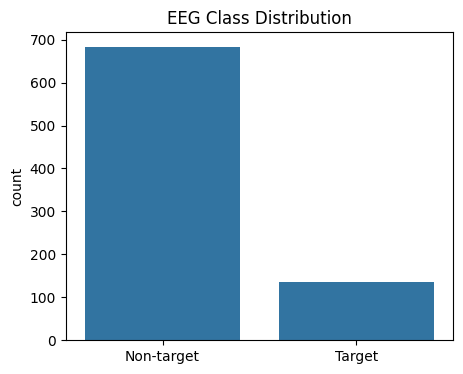

Training data: (655, 64, 206)
Testing data: (164, 64, 206)


In [50]:
# Check Target / Non-target distribution

print("Non-target samples:", np.sum(y == 0))
print("Target samples:", np.sum(y == 1))

plt.figure(figsize=(5, 4))

sns.countplot(
    x=y
)

plt.xticks(
    [0, 1],
    ["Non-target", "Target"]
)

plt.title("EEG Class Distribution")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

In [51]:
# Build a compact TCFNet-style neural network

inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = Conv1D(
    32,
    kernel_size=7,
    padding="same"
)(inputs)

x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(
    64,
    kernel_size=5,
    padding="same"
)(x)

x = BatchNormalization()(x)
x = Activation("relu")(x)

x = LSTM(
    64,
    return_sequences=True
)(x)

# Fuzzy-style membership layer
membership = Dense(
    64,
    activation="sigmoid"
)(x)

x = Multiply()([
    x,
    membership
])

x = GlobalAveragePooling1D()(x)

x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(0.4)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs,
    outputs
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 206)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 64, 32)    │     46,176 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 32)    │        128 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 32, 32)    │          0 │ activation_5[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 32, 64)    │     10,304 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 32, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32, 64)    │     33,024 │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32, 64)    │      4,160 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32, 64)    │          0 │ lstm_1[0][0],     │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 98,273 (383.88 KB)

 Trainable params: 98,081 (383.13 KB)

 Non-trainable params: 192 (768.00 B)

In [59]:
# Train using class weights to handle Target/Non-target imbalance

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Class weights:
{np.int64(0): np.float64(0.5998168498168498), np.int64(1): np.float64(3.0045871559633026)}
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.7996 - loss: 0.7039 - val_accuracy: 0.7023 - val_loss: 0.5803
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6641 - loss: 0.5912 - val_accuracy: 0.6794 - val_loss: 0.5942
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7576 - loss: 0.5120 - val_accuracy: 0.7405 - val_loss: 0.5838
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8187 - loss: 0.4410 - val_accuracy: 0.7252 - val_loss: 0.6069
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8454 - loss: 0.3747 - val_accuracy: 0.6641 - val_loss: 0.7271
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8664 - loss: 0.3366 - val_accuracy: 0.6870 - val_loss: 0.6645


In [66]:
# Train the AI model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.7080 - loss: 0.6033 - val_accuracy: 0.7328 - val_loss: 0.5432
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7366 - loss: 0.5279 - val_accuracy: 0.6565 - val_loss: 0.6109
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8206 - loss: 0.4269 - val_accuracy: 0.6794 - val_loss: 0.6223
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8321 - loss: 0.3905 - val_accuracy: 0.6718 - val_loss: 0.8051
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8130 - loss: 0.3876 - val_accuracy: 0.5344 - val_loss: 0.8255
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8206 - loss: 0.3422 - val_accuracy: 0.7557 - val_loss: 0.5350
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8588 - loss: 0.2847 - val_accuracy: 0.6565 - val_loss: 0.8105
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9313 - loss: 0.2188 - val_accuracy: 0.6718 - 

In [67]:
# Evaluate the trained model

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Loss: 0.6338
Test Accuracy: 72.56%


In [68]:
# Generate predictions

y_prob = model.predict(
    X_test,
    verbose=0
).ravel()

y_pred = (
    y_prob >= 0.5
).astype(int)

print(
    "Predicted Non-target:",
    np.sum(y_pred == 0)
)

print(
    "Predicted Target:",
    np.sum(y_pred == 1)
)

print(
    "\nActual Non-target:",
    np.sum(y_test == 0)
)

print(
    "Actual Target:",
    np.sum(y_test == 1)
)

Predicted Non-target: 130
Predicted Target: 34

Actual Non-target: 137
Actual Target: 27


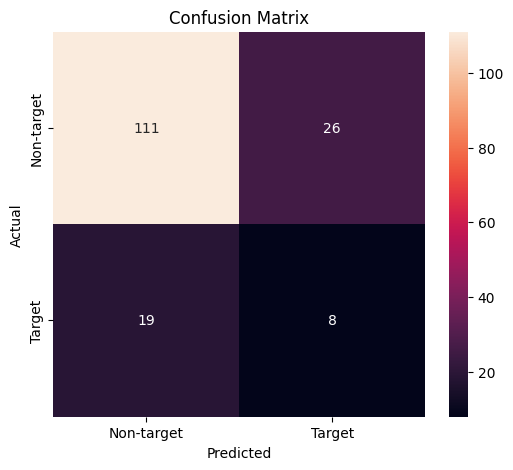

              precision    recall  f1-score   support

  Non-target       0.85      0.81      0.83       137
      Target       0.24      0.30      0.26        27

    accuracy                           0.73       164
   macro avg       0.54      0.55      0.55       164
weighted avg       0.75      0.73      0.74       164



In [69]:
# Evaluate Target and Non-target classification

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Non-target",
        "Target"
    ],
    yticklabels=[
        "Non-target",
        "Target"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.show()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Non-target",
            "Target"
        ]
    )
)

In [78]:
# Select the smart-home appliance

print("Available appliances:")
print("1. Light")
print("2. Fan")
print("3. TV")
print("4. AC")

appliance_input = input("\nEnter appliance: ").strip().lower()

appliance_map = {
    "light": "Light",
    "fan": "Fan",
    "tv": "TV",
    "ac": "AC"
}

if appliance_input in appliance_map:

    appliance = appliance_map[appliance_input]

    print("\nSelected appliance:", appliance)

else:

    appliance = None

    print("\nInvalid appliance.")
    print("Please enter: Light, Fan, TV, or AC")

Available appliances:
1. Light
2. Fan
3. TV
4. AC

Enter appliance: tv

Selected appliance: TV


In [79]:
# Find a test EEG sample that the model predicts as Target

target_indices = np.where(
    y_pred == 1
)[0]

correct_target_indices = np.where(
    (y_test == 1) &
    (y_pred == 1)
)[0]

print(
    "Total Target predictions:",
    len(target_indices)
)

print(
    "Correct Target predictions:",
    len(correct_target_indices)
)

if len(correct_target_indices) > 0:

    sample_number = (
        correct_target_indices[0]
    )

    print(
        "\nUsing correctly predicted Target sample:",
        sample_number + 1
    )

    print(
        "Target probability:",
        round(
            float(y_prob[sample_number]),
            4
        )
    )

else:

    sample_number = None

    print(
        "\nNo correctly predicted Target sample."
    )

Total Target predictions: 34
Correct Target predictions: 8

Using correctly predicted Target sample: 17
Target probability: 0.9071


In [80]:
# Generate final smart-home command

if appliance not in [
    "Light",
    "Fan",
    "TV",
    "AC"
]:

    print(
        "Please enter a valid appliance."
    )

elif sample_number is None:

    print(
        "No correctly predicted Target "
        "sample is available."
    )

else:

    prediction = y_pred[
        sample_number
    ]

    print("=" * 45)
    print("       SMART HOME BCI OUTPUT")
    print("=" * 45)

    print(
        "Appliance:",
        appliance
    )

    print(
        "EEG Prediction:",
        "Target"
        if prediction == 1
        else "Non-target"
    )

    print(
        "Target Probability:",
        round(
            float(y_prob[sample_number]),
            4
        )
    )

    if prediction == 1:

        print("Command: ON")

        if appliance == "Light":
            print("💡 LIGHT ON")

        elif appliance == "Fan":
            print("🌀 FAN ON")

        elif appliance == "TV":
            print("📺 TV ON")

        elif appliance == "AC":
            print("❄️ AC ON")

    else:

        print("Command: OFF")

        if appliance == "Light":
            print("⚫ LIGHT OFF")

        elif appliance == "Fan":
            print("⚫ FAN OFF")

        elif appliance == "TV":
            print("⚫ TV OFF")

        elif appliance == "AC":
            print("⚫ AC OFF")

    print("=" * 45)

       SMART HOME BCI OUTPUT
Appliance: TV
EEG Prediction: Target
Target Probability: 0.9071
Command: ON
📺 TV ON


In [81]:
# Display examples of how the EEG prediction controls appliances

print("SMART HOME COMMAND MAPPING")
print("=" * 45)

print("\nIf EEG = Target:")
print("💡 Light → ON")
print("🌀 Fan   → ON")
print("📺 TV    → ON")
print("❄️ AC    → ON")

print("\nIf EEG = Non-target:")
print("💡 Light → OFF")
print("🌀 Fan   → OFF")
print("📺 TV    → OFF")
print("❄️ AC    → OFF")

SMART HOME COMMAND MAPPING

If EEG = Target:
💡 Light → ON
🌀 Fan   → ON
📺 TV    → ON
❄️ AC    → ON

If EEG = Non-target:
💡 Light → OFF
🌀 Fan   → OFF
📺 TV    → OFF
❄️ AC    → OFF


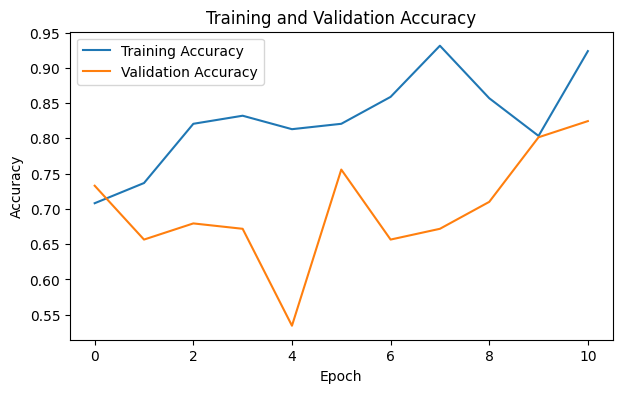

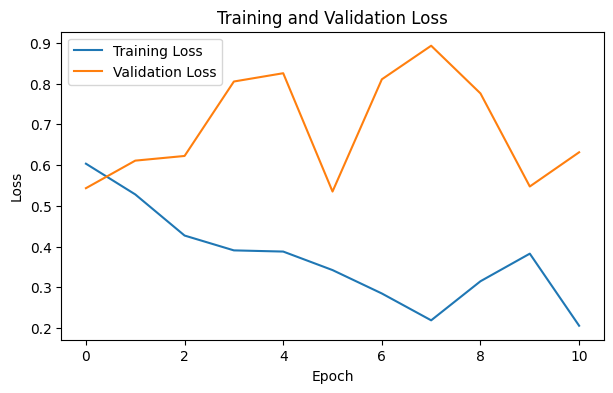

In [82]:
# Plot training and validation accuracy

plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.show()


# Plot loss

plt.figure(figsize=(7, 4))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.show()

In [83]:
# Save trained model and processed EEG data

model.save(
    "/content/P300_TCFNet_Prototype.keras"
)

np.save(
    "/content/P300_X_processed.npy",
    X
)

np.save(
    "/content/P300_y_labels.npy",
    y
)

print("Saved successfully!")

print(
    "/content/P300_TCFNet_Prototype.keras"
)

print(
    "/content/P300_X_processed.npy"
)

print(
    "/content/P300_y_labels.npy"
)

Saved successfully!
/content/P300_TCFNet_Prototype.keras
/content/P300_X_processed.npy
/content/P300_y_labels.npy
